# _4.4.4. (Fine-Grained) classification using TabNet_


Main topics of the current notebook is to focus on applying TabNet to the problem of anomaly detection, i.e., identifying anomaly severity levels ranging from 5% to 50%, along with encompassing categories : reorder, duplicate, corrupt anpmalies or a normal case. 


#### _a. Load Data_

Recall, the dataset was already cleaned and normalized _(using StandardScaler)_. Columns with zero or near-zero variance deleted.

In [1]:
!jupyter nbextension enable --py widgetsnbextension

Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: ok


In [2]:
import pandas as pd
import numpy as np
import os
import time
import torch

from matplotlib import pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.model_selection import train_test_split

from pytorch_tabnet.tab_model import TabNetClassifier

%matplotlib inline

In [3]:
scaled_new_dataset = "data/scaled_new_godash_dataset.csv"
scaled_new_df = pd.read_csv(scaled_new_dataset, index_col=0)

scaled_new_df.head(2)

,Seg_id,Arr_time,Del_Time,Stall_Dur,Rep_Level,Del_Rate,Act_Rate,Byte_Size,Buff_Level,Width,...,Yu,algo,nb_nodes,mos,MOS,mos_label,anomaly,level,tag2,tag
0,-1.697807,-0.445033,-0.204334,-0.164204,-1.294465,-1.160341,-1.160370,-1.160361,-0.833377,-1.247338,...,0.360347,-1.462647,0.524565,-1.043858,-0.045817,bad,0,-1.083746,False,0
1,-1.640070,-0.441006,-0.198458,-0.164204,-1.294465,-0.396335,-1.008632,-1.008502,-0.575036,-1.247338,...,0.360347,-1.462647,0.524565,-1.114816,-0.045817,bad,0,-1.083746,False,0


In [4]:
n_total = len(scaled_new_df)
print ("n_total = ", n_total)
print ("nb features =", len(scaled_new_df.columns))
print ("nan values =", scaled_new_df.isna().sum().sum())

n_total =  85596
nb features = 27
nan values = 0


In [8]:
all_features = ['Seg_id', 'Arr_time', 'Del_Time', 'Stall_Dur', 'Rep_Level', 'Del_Rate',
                'Act_Rate', 'Byte_Size', 'Buff_Level',  'Width',
                'Height', 'Play_Pos', 'RTT',  'P.1203', 'Clae',
                'Duanmu', 'Yin', 'Yu', 'algo', 'nb_nodes', 'mos', 'MOS', 'mos_label', 
                'anomaly', 'level', 'tag2', 'tag']
new_df = scaled_new_df [all_features]
selected_features = all_features[:-4]
target = "tag"

In [9]:
dataset_name = 'new_godash_dataset'
train = new_df.copy()
n_total = len(train)
print ("n_total = ", n_total)
print ("nb features =", len(train.columns))
print ("nan values =", train.isna().sum().sum())

n_total =  85596
nb features = 27
nan values = 0


#### _b. Label Encode target y_

The basic Idea here is to see the problem as a multi-class classification problem. 

The population is already devided into different anomalies tag using "tag" column.

In [10]:
# 'normal':0, 
# 'reorder5':1, 'reorder10':2, 'reorder20':3, 'reorder30':4, 'reorder40':5, 'reorder50':6,
# 'duplicate5':7, 'duplicate10':8, 'duplicate20':9, 'duplicate30':10, 'duplicate40':11, 'duplicate50':12,        
# 'corrupt5':13,   'corrupt10':14,   'corrupt20':15, 'corrupt30':16,  'corrupt40':17,  'corrupt50':18
train[target].value_counts(normalize=True)

0     0.253049
15    0.042058
3     0.042058
14    0.042058
1     0.042058
2     0.042058
7     0.042058
6     0.042058
13    0.042058
8     0.042058
9     0.042058
4     0.042058
16    0.042058
12    0.042058
5     0.042058
10    0.042058
11    0.042058
17    0.041182
18    0.032840
Name: tag, dtype: float64

#### _c. Split_

In [11]:
train_val_indices, test_indices = train_test_split(range(n_total), test_size=0.2, random_state=0)
train_indices, valid_indices = train_test_split(train_val_indices, test_size=0.2 / 0.6, random_state=0)

# This is a generic pipeline but actually no categorical features are available for this dataset
unused_feat = ["mos_label", 'anomaly', 'level', 'tag']
features = [ col for col in selected_features if col not in unused_feat+[target]] 

X_train = train[features].values[train_indices]
y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("X_train (shape) = ", X_train.shape, "--> ", round((X_train.shape[0]/train.shape[0])*100,2), "%")
print ("X_valid (shape) = ", X_valid.shape, "--> ", round((X_valid.shape[0]/train.shape[0])*100,2), "%")
print ("X_test (shape)  = ", X_test.shape, "--> ", round((X_test.shape[0]/train.shape[0])*100,2), "%\n\n")

print ("y_train (shape) = ", y_train.shape)
print ("y_valid (shape) = ", y_valid.shape)
print ("y_test (shape)  = ", y_test.shape)

X_train (shape) =  (45650, 22) -->  53.33 %
X_valid (shape) =  (22826, 22) -->  26.67 %
X_test (shape)  =  (17120, 22) -->  20.0 %


y_train (shape) =  (45650,)
y_valid (shape) =  (22826,)
y_test (shape)  =  (17120,)


##### _d. Categorical features_

We need to identify categorical features before training in Tabnet

In [12]:
nunique = train.nunique()
types = train.dtypes

categorical_columns = []
categorical_dims =  {}
for col in train.columns:
    if types[col] == 'object' or nunique[col] < 200:
        print(col, train[col].nunique())
        l_enc = LabelEncoder()
        train[col] = train[col].fillna("VV_likely")
        train[col] = l_enc.fit_transform(train[col].values)
        categorical_columns.append(col)
        categorical_dims[col] = len(l_enc.classes_)

Seg_id 60
Rep_Level 8
Width 6
Height 6
Play_Pos 60
algo 6
nb_nodes 10
MOS 5
mos_label 5
anomaly 4
level 7
tag2 2
tag 19


In [13]:
cat_idxs = [ i for i, f in enumerate(features) if f in categorical_columns]
cat_dims = [ categorical_dims[f] for i, f in enumerate(features) if f in categorical_columns]

pd.DataFrame({"cathegorical_features" : np.array(features)[cat_idxs],\
              "feat_index" : cat_idxs,\
              "cat_dimention" : cat_dims })

,cathegorical_features,feat_index,cat_dimention
0,Seg_id,0,60
1,Rep_Level,4,8
2,Width,9,6
3,Height,10,6
4,Play_Pos,11,60
5,algo,18,6
6,nb_nodes,19,10
7,MOS,21,5


In [14]:
X_train = train[features].values[train_indices]
y_train = train[target].values[train_indices]

X_valid = train[features].values[valid_indices]
y_valid = train[target].values[valid_indices]

X_test = train[features].values[test_indices]
y_test = train[target].values[test_indices]

print ("X_train (shape) = ", X_train.shape, "--> ", round((X_train.shape[0]/train.shape[0])*100,2), "%")
print ("X_valid (shape) = ", X_valid.shape, "--> ", round((X_valid.shape[0]/train.shape[0])*100,2), "%")
print ("X_test (shape)  = ", X_test.shape, "--> ", round((X_test.shape[0]/train.shape[0])*100,2), "%\n\n")

print ("y_train (shape) = ", y_train.shape)
print ("y_valid (shape) = ", y_valid.shape)
print ("y_test (shape)  = ", y_test.shape)

X_train (shape) =  (45650, 22) -->  53.33 %
X_valid (shape) =  (22826, 22) -->  26.67 %
X_test (shape)  =  (17120, 22) -->  20.0 %


y_train (shape) =  (45650,)
y_valid (shape) =  (22826,)
y_test (shape)  =  (17120,)


##### _f. Grouped features_

You can now specify groups of feature which will share a common attention.

This may be very usefull for features comming from a same preprocessing technique like PCA for example.

In [15]:
grouped_features = [[0, 1, 2], [8, 9, 10]]
pd.DataFrame({"group_01" : np.array(features)[grouped_features[0]],\
              "group_02" : np.array(features)[grouped_features[1]]})

,group_01,group_02
0,Seg_id,Buff_Level
1,Arr_time,Width
2,Del_Time,Height


#### _g. Check CUDA support_

In [16]:
print ("Is CUDA available :", torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print ("Device :", DEVICE)

Is CUDA available : True
Device : cuda


In [17]:
os.environ['CUDA_VISIBLE_DEVICES'] = f"1"

print ("Is Torsh available --> ", torch.cuda.is_available())
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DEVICE 

Is Torsh available -->  True


'cuda'

In [18]:
torch.__version__

'1.9.0+cu111'

In [20]:
from pytorch_tabnet.augmentations import ClassificationSMOTE
aug = ClassificationSMOTE(p=0.2)

### _h. Classification using TabNet_

While traditional vanilla _**neural networks**_ can be powerful, they may encounter certain pitfalls in the context of anomaly detection _(motivating the exploration of alternative architectures)_ 

This includes :

-  Lack of support of Sequential/Tabular Data 

-  Lack of Interpretability


Developed by Google Cloud AI researchers, _**TabNet**_ introduces innovations that make it well-suited for tasks involving datasets with rows and columns, and where interpretability is a critical requirement.


<br>

<div style="float: center;"><img  src="docs\pics\tabnet_google.png"  alt="binary_nn"  width="400"/>
</div>

</br>

We used [**_dreamquark-ai/tabnet_**](https://github.com/dreamquark-ai/tabnet), a **_PyTorsh_** implementation of tabnet based on the [[original paper]](https://arxiv.org/pdf/1908.07442.pdf). 

As an hyper-parameter-tuning, we have to choose between _**AUC**_ vs _**logloss**_ as an _**evaluation metric**_. 

### _1. Using AUC_

In [19]:
clf = TabNetClassifier(
    n_d=64, n_a=64, n_steps=5,
    gamma=1.5, n_independent=2, n_shared=2,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=1,
    lambda_sparse=1e-4, momentum=0.3, clip_value=2.,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params = {"gamma": 0.95, "step_size": 20},
    scheduler_fn=torch.optim.lr_scheduler.StepLR, epsilon=1e-15,
    device_name = DEVICE
)

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [20]:
X_valid.shape

(22826, 22)

In [21]:
max_epochs = 100 if not os.getenv("CI", False) else 2
from pytorch_tabnet.augmentations import ClassificationSMOTE
aug = ClassificationSMOTE(p=0.2)

clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_name=['train', 'valid'],
    max_epochs=max_epochs, patience=100,
    batch_size=22826, virtual_batch_size=256,
    # batch_size=1024, virtual_batch_size=256,    
    augmentations=aug
) 

epoch 0  | loss: 6.94565 | train_accuracy: 0.04892 | valid_accuracy: 0.04885 |  0:00:03s
epoch 1  | loss: 4.36926 | train_accuracy: 0.15584 | valid_accuracy: 0.15623 |  0:00:05s
epoch 2  | loss: 3.40043 | train_accuracy: 0.26653 | valid_accuracy: 0.26939 |  0:00:07s
epoch 3  | loss: 3.30025 | train_accuracy: 0.26618 | valid_accuracy: 0.27215 |  0:00:09s
epoch 4  | loss: 3.05429 | train_accuracy: 0.25176 | valid_accuracy: 0.25217 |  0:00:12s
epoch 5  | loss: 2.85529 | train_accuracy: 0.26631 | valid_accuracy: 0.27276 |  0:00:14s
epoch 6  | loss: 2.72459 | train_accuracy: 0.2835  | valid_accuracy: 0.28708 |  0:00:16s
epoch 7  | loss: 2.60824 | train_accuracy: 0.28458 | valid_accuracy: 0.28958 |  0:00:18s
epoch 8  | loss: 2.53041 | train_accuracy: 0.29356 | valid_accuracy: 0.29817 |  0:00:21s
epoch 9  | loss: 2.45582 | train_accuracy: 0.30686 | valid_accuracy: 0.30746 |  0:00:23s
epoch 10 | loss: 2.3749  | train_accuracy: 0.32585 | valid_accuracy: 0.3259  |  0:00:25s
epoch 11 | loss: 2.35

epoch 93 | loss: 1.84778 | train_accuracy: 0.40248 | valid_accuracy: 0.40454 |  0:03:30s
epoch 94 | loss: 1.85067 | train_accuracy: 0.38609 | valid_accuracy: 0.3857  |  0:03:33s
epoch 95 | loss: 1.84677 | train_accuracy: 0.397   | valid_accuracy: 0.39924 |  0:03:35s
epoch 96 | loss: 1.84799 | train_accuracy: 0.42478 | valid_accuracy: 0.42438 |  0:03:37s
epoch 97 | loss: 1.84584 | train_accuracy: 0.41687 | valid_accuracy: 0.41628 |  0:03:39s
epoch 98 | loss: 1.84967 | train_accuracy: 0.41297 | valid_accuracy: 0.41168 |  0:03:41s
epoch 99 | loss: 1.84059 | train_accuracy: 0.42598 | valid_accuracy: 0.42649 |  0:03:43s
Stop training because you reached max_epochs = 100 with best_epoch = 99 and best_valid_accuracy = 0.42649


C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


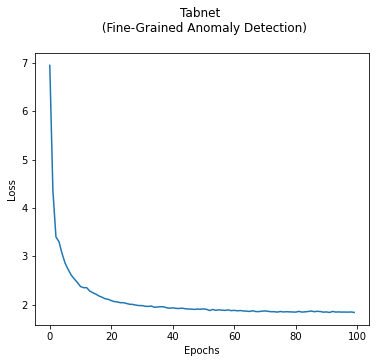

In [22]:
# plot losses
plt.figure(figsize=(6,5))
plt.plot(clf.history['loss'])
plt.title('Tabnet \n (Fine-Grained Anomaly Detection)\n')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

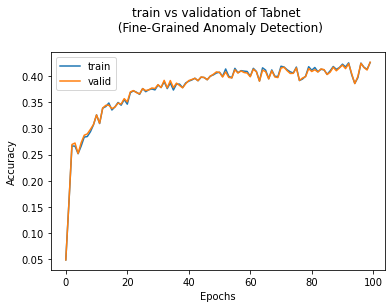

In [23]:
plt.plot(clf.history['train_accuracy'], label="train")
plt.plot(clf.history['valid_accuracy'], label="valid")
plt.title('train vs validation of Tabnet \n (Fine-Grained Anomaly Detection)\n')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

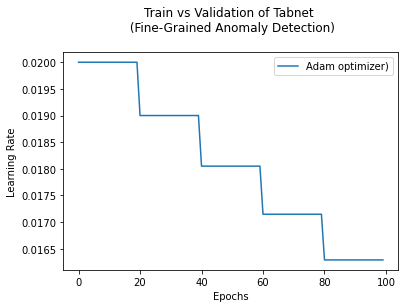

In [24]:
# plot learning rates
plt.plot(clf.history['lr'], label="Adam optimizer)")
plt.title('Train vs Validation of Tabnet \n (Fine-Grained Anomaly Detection)\n')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.legend()

##### _Evaluate_

In [25]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_valid = clf.predict(X_valid)
y_pred_train = clf.predict(X_train)
y_pred_test = clf.predict(X_test)

# Calculate accuracy
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Validation Accuracy:", valid_accuracy)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Validation Accuracy: 0.4264873389993867
Train Accuracy: 0.4259802847754655
Test Accuracy: 0.42429906542056073


Evaluate using test set :

In [26]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_test = clf.predict(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.42429906542056073


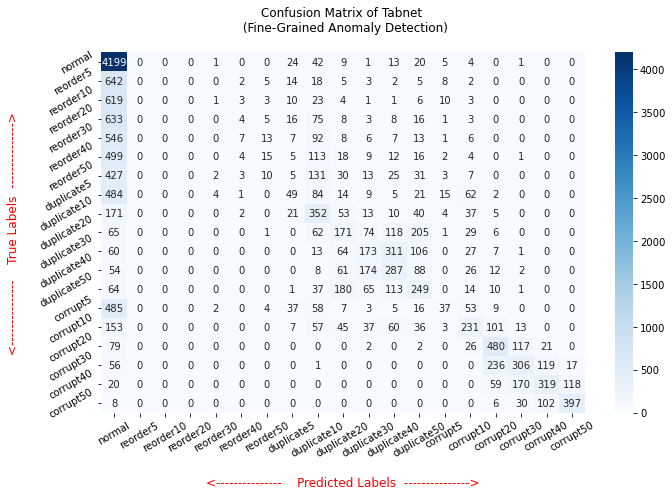

In [29]:
from sklearn.metrics import confusion_matrix, classification_report


# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

import seaborn as sns
import matplotlib.pyplot as plt

labeled_classes = [ 'normal', 
                    'reorder5', 'reorder10', 'reorder20', 
                    'reorder30', 'reorder40', 'reorder50',
                   'duplicate5', 'duplicate10', 'duplicate20', 
                    'duplicate30', 'duplicate40', 'duplicate50',        
                    'corrupt5',   'corrupt10',   'corrupt20', 
                    'corrupt30',  'corrupt40',  'corrupt50']

classes = np.unique(y_train) 
classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labeled_classes, rotation=30)
plt.yticks(classes, labeled_classes, rotation=30)
plt.xlabel("<---------------    Predicted Labels  --------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<---------------    True Labels  --------------->",  fontsize=12, color="red", labelpad=18)
plt.title('Confusion Matrix of Tabnet \n (Fine-Grained Anomaly Detection)\n')
plt.tight_layout()
plt.show()

In [30]:
# Display a classification report
print("                  TabNet Classification Report")
print("                (Fine-Grained Anomaly Detection)\n")
print(classification_report(y_test, y_pred_test))

                  TabNet Classification Report
                (Fine-Grained Anomaly Detection)

              precision    recall  f1-score   support

           0       0.45      0.97      0.62      4319
           1       0.00      0.00      0.00       706
           2       0.00      0.00      0.00       684
           3       0.00      0.00      0.00       772
           4       0.00      0.00      0.00       706
           5       0.15      0.01      0.01       698
           6       0.18      0.01      0.03       687
           7       0.25      0.07      0.10       750
           8       0.30      0.50      0.38       708
           9       0.25      0.23      0.24       732
          10       0.30      0.23      0.26       762
          11       0.29      0.40      0.34       712
          12       0.29      0.34      0.31       734
          13       0.41      0.05      0.09       716
          14       0.43      0.31      0.36       743
          15       0.51      0.66     

C:\Users\kabou\.conda\envs\py37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\kabou\.conda\envs\py37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\kabou\.conda\envs\py37\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


##### _Global explainability : feat importance summing to 1_

In [31]:
scorez = clf.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(20)

,feature,score,f_indice,rank
0,Del_Rate,0.280193,5,1
1,P.1203,0.132688,13,2
2,Height,0.092758,10,3
3,Arr_time,0.086122,1,4
4,Yin,0.067209,16,5
5,Buff_Level,0.055121,8,6
6,RTT,0.039561,12,7
7,Act_Rate,0.032324,6,8
8,Width,0.029336,9,9
9,Duanmu,0.024575,15,10


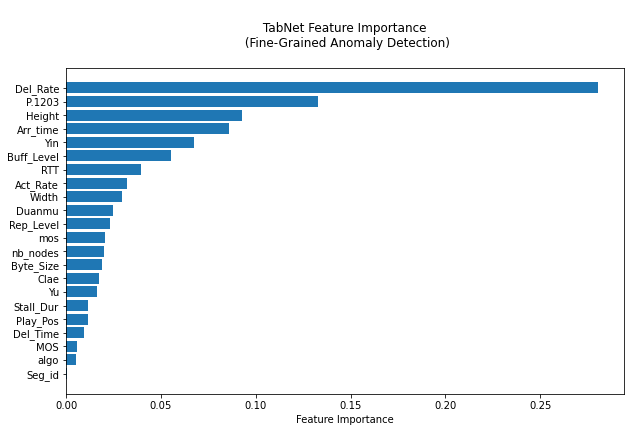

In [32]:
feature_importance = clf.feature_importances_

# Map feature names to importance scores
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("\n TabNet Feature Importance \n (Fine-Grained Anomaly Detection)\n")
plt.show()

#### _Local explainability and masks_

In [33]:
explain_matrix, masks = clf.explain(X_test)
print (masks.keys())
masks[0][:50].shape

dict_keys([0, 1, 2, 3, 4])


(50, 22)

In [34]:
tabnet_params = {"cat_idxs":cat_idxs,
                 "cat_dims":cat_dims,
                 "cat_emb_dim":2,
                 "optimizer_fn":torch.optim.Adam,
                 "optimizer_params":dict(lr=2e-2),
                 "scheduler_params":{"step_size":50, # how to use learning rate scheduler
                                 "gamma":0.9},
                 "scheduler_fn":torch.optim.lr_scheduler.StepLR,
                 "mask_type":'entmax', # "sparsemax"
                 ##"grouped_features" : grouped_features,
                  "device_name" : "auto"                 
                }

acc_clf = TabNetClassifier(**tabnet_params)

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


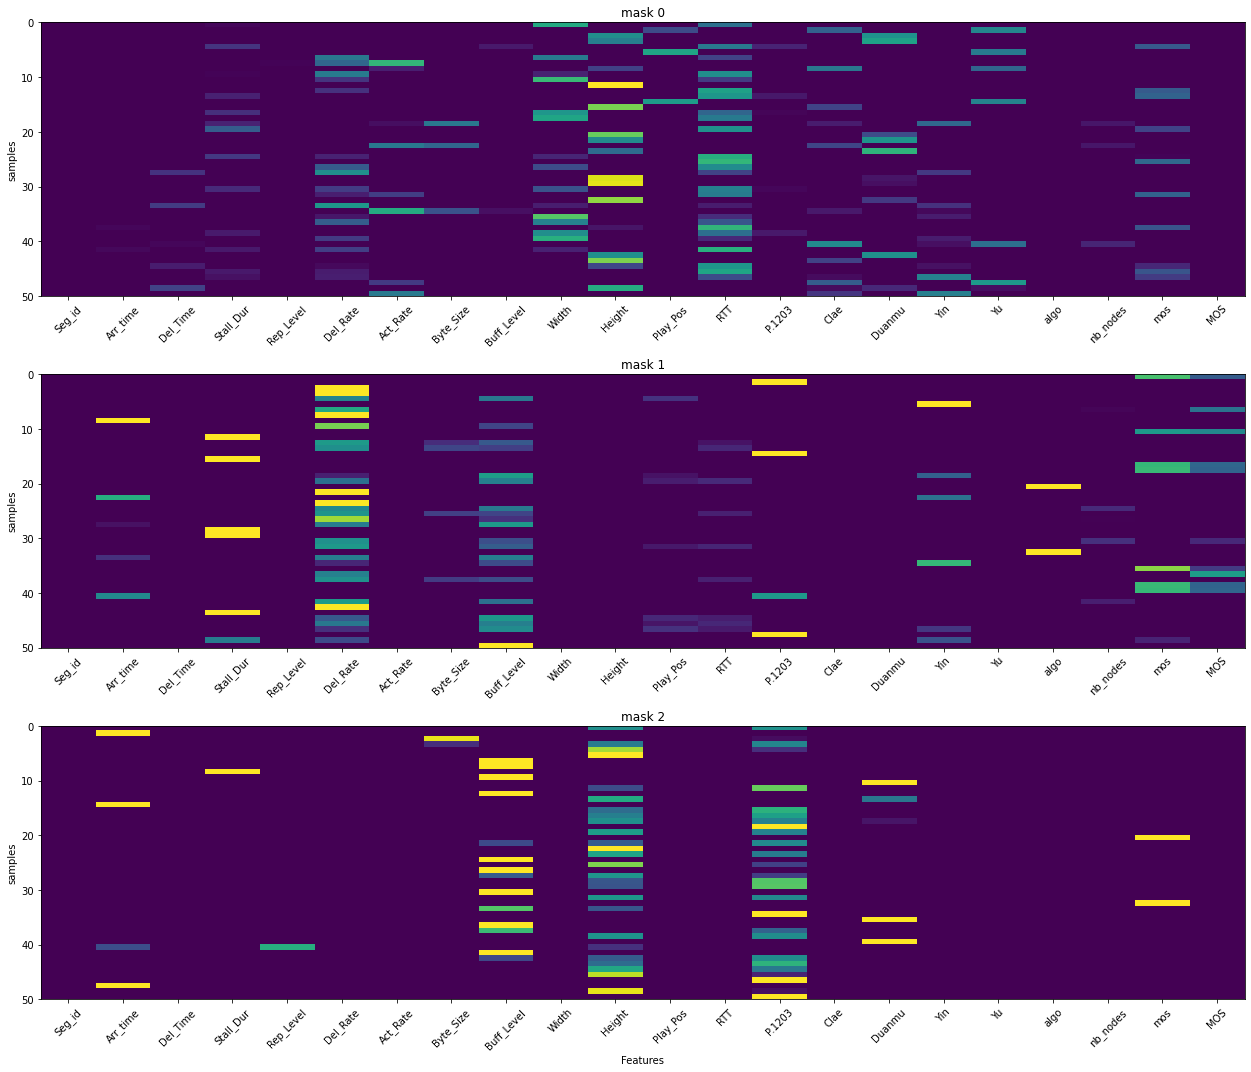

In [35]:
fig, axs = plt.subplots(3, 1, figsize=(20,15))
features_index = [x*20+10 for x in range(len(features))]
for i in range(3):
    axs[i].set_xticks(features_index)
    axs[i].imshow(masks[i][:50], extent=[0, 440, 50, 0], aspect=2)
    axs[i].set_xticklabels(features, rotation=45)
    axs[i].set_title(f"mask {i}")
    axs[i].set_ylabel("samples")    
axs[i].set_xlabel("Features")    
fig.tight_layout()

### _1. Using Accuracy as an Evaluation metric_ 

In [36]:
max_epochs = 100 if not os.getenv("CI", False) else 2

from pytorch_tabnet.augmentations import ClassificationSMOTE
aug = ClassificationSMOTE(p=0.2)

In [37]:
# This illustrates the warm_start=False behaviour
save_history = []
start_time = time.time()

# Fitting the model without starting from a warm start nor computing the feature importance
for _ in range(2):
    acc_clf.fit(
        X_train=X_train, y_train=y_train,
        eval_set=[(X_train, y_train), (X_valid, y_valid)],
        eval_name=['train', 'valid'],
        eval_metric=['accuracy'],
        max_epochs=max_epochs , # max_epochs=11, patience=20,
        batch_size=1024, virtual_batch_size=128,
        num_workers=0,
        weights=1,
        drop_last=False,
        augmentations=aug, #aug, None
        compute_importance=True
    )
    save_history.append(acc_clf.history["valid_accuracy"])

assert(np.all(np.array(save_history[0]==np.array(save_history[1]))))

print(f"Training completed in {(time.time()-start_time)//60:.2f} mnt.")

epoch 0  | loss: 2.77458 | train_accuracy: 0.12322 | valid_accuracy: 0.12105 |  0:00:05s
epoch 1  | loss: 2.2536  | train_accuracy: 0.25108 | valid_accuracy: 0.25015 |  0:00:11s
epoch 2  | loss: 2.06995 | train_accuracy: 0.25693 | valid_accuracy: 0.25782 |  0:00:18s
epoch 3  | loss: 1.95192 | train_accuracy: 0.33192 | valid_accuracy: 0.32765 |  0:00:24s
epoch 4  | loss: 1.8489  | train_accuracy: 0.42581 | valid_accuracy: 0.4324  |  0:00:30s
epoch 5  | loss: 1.7669  | train_accuracy: 0.31801 | valid_accuracy: 0.32056 |  0:00:36s
epoch 6  | loss: 1.72624 | train_accuracy: 0.41415 | valid_accuracy: 0.41334 |  0:00:42s
epoch 7  | loss: 1.71184 | train_accuracy: 0.33831 | valid_accuracy: 0.33563 |  0:00:48s
epoch 8  | loss: 1.66729 | train_accuracy: 0.29796 | valid_accuracy: 0.29497 |  0:00:55s
epoch 9  | loss: 1.65996 | train_accuracy: 0.37814 | valid_accuracy: 0.37374 |  0:01:01s
epoch 10 | loss: 1.62647 | train_accuracy: 0.49398 | valid_accuracy: 0.49785 |  0:01:07s
epoch 11 | loss: 1.62

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


epoch 0  | loss: 2.77458 | train_accuracy: 0.12322 | valid_accuracy: 0.12105 |  0:00:05s
epoch 1  | loss: 2.2536  | train_accuracy: 0.25108 | valid_accuracy: 0.25015 |  0:00:11s
epoch 2  | loss: 2.06995 | train_accuracy: 0.25693 | valid_accuracy: 0.25782 |  0:00:17s
epoch 3  | loss: 1.95192 | train_accuracy: 0.33192 | valid_accuracy: 0.32765 |  0:00:22s
epoch 4  | loss: 1.8489  | train_accuracy: 0.42581 | valid_accuracy: 0.4324  |  0:00:28s
epoch 5  | loss: 1.7669  | train_accuracy: 0.31801 | valid_accuracy: 0.32056 |  0:00:34s
epoch 6  | loss: 1.72624 | train_accuracy: 0.41415 | valid_accuracy: 0.41334 |  0:00:40s
epoch 7  | loss: 1.71184 | train_accuracy: 0.33831 | valid_accuracy: 0.33563 |  0:00:45s
epoch 8  | loss: 1.66729 | train_accuracy: 0.29796 | valid_accuracy: 0.29497 |  0:00:51s
epoch 9  | loss: 1.65996 | train_accuracy: 0.37814 | valid_accuracy: 0.37374 |  0:00:57s
epoch 10 | loss: 1.62647 | train_accuracy: 0.49398 | valid_accuracy: 0.49785 |  0:01:02s
epoch 11 | loss: 1.62

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training completed in 5.00 mnt.


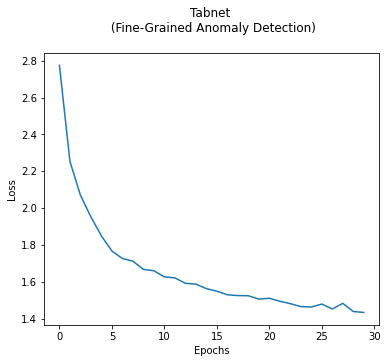

In [38]:
# plot losses
plt.figure(figsize=(6,5))
plt.plot(acc_clf.history['loss'])
plt.title('Tabnet \n (Fine-Grained Anomaly Detection)\n')
plt.xlabel('Epochs')
plt.ylabel('Loss')
#plt.legend()
plt.show()

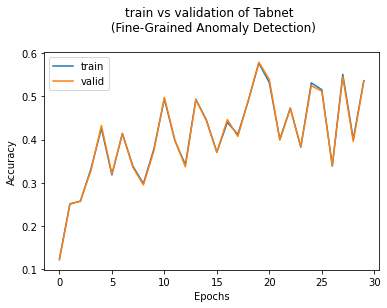

In [39]:
# plot acc
plt.plot(acc_clf.history['train_accuracy'], label="train")
plt.plot(acc_clf.history['valid_accuracy'], label="valid")

plt.title('train vs validation of Tabnet \n (Fine-Grained Anomaly Detection)\n')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

##### _Evaluate_

In [40]:
from sklearn.metrics import silhouette_score, accuracy_score, mean_squared_error, r2_score

# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_valid = acc_clf.predict(X_valid)
y_pred_train = acc_clf.predict(X_train)
y_pred_test = acc_clf.predict(X_test)

# Calculate accuracy
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Validation Accuracy:", valid_accuracy)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Validation Accuracy: 0.5790764917199684
Train Accuracy: 0.5771522453450164
Test Accuracy: 0.5721378504672897


Evaluate using test set :

In [41]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_test = acc_clf.predict(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.5721378504672897


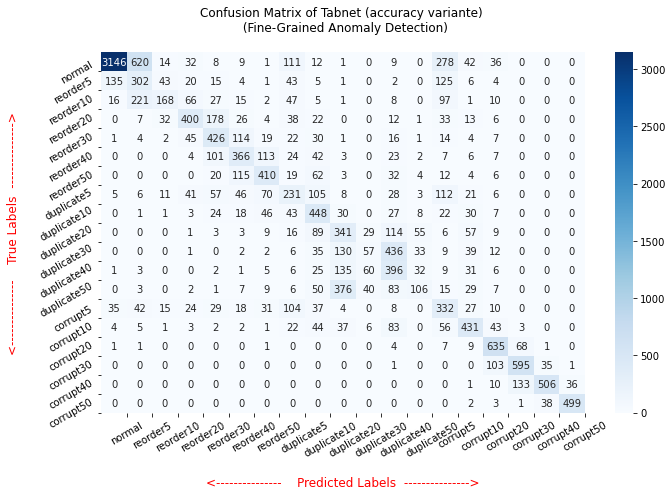

In [42]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

import seaborn as sns
import matplotlib.pyplot as plt


labaled_classes = [ 'normal', 
                    'reorder5', 'reorder10', 'reorder20', 
                    'reorder30', 'reorder40', 'reorder50',
                   'duplicate5', 'duplicate10', 'duplicate20', 
                    'duplicate30', 'duplicate40', 'duplicate50',        
                    'corrupt5',   'corrupt10',   'corrupt20', 
                    'corrupt30',  'corrupt40',  'corrupt50']

classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labeled_classes, rotation=30)
plt.yticks(classes, labeled_classes, rotation=30)
plt.xlabel("<---------------    Predicted Labels  --------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<---------------    True Labels  --------------->",  fontsize=12, color="red", labelpad=18)
plt.title('Confusion Matrix of Tabnet (accuracy variante) \n (Fine-Grained Anomaly Detection)\n')
plt.tight_layout()
plt.show()

In [43]:
# Display a classification report
print("                  TabNet Classification Report")
print("                (Fine-Grained Anomaly Detection)\n")
print(classification_report(y_test, y_pred_test))

                  TabNet Classification Report
                (Fine-Grained Anomaly Detection)

              precision    recall  f1-score   support

           0       0.94      0.73      0.82      4319
           1       0.25      0.43      0.31       706
           2       0.59      0.25      0.35       684
           3       0.62      0.52      0.57       772
           4       0.48      0.60      0.53       706
           5       0.49      0.52      0.51       698
           6       0.57      0.60      0.58       687
           7       0.31      0.31      0.31       750
           8       0.44      0.63      0.52       708
           9       0.32      0.47      0.38       732
          10       0.30      0.07      0.12       762
          11       0.31      0.56      0.40       712
          12       0.43      0.14      0.22       734
          13       0.29      0.46      0.36       716
          14       0.57      0.58      0.58       743
          15       0.69      0.87     

##### _Global explainability : feat importance summing to 1_

In [44]:
scorez = acc_clf.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(20)

,feature,score,f_indice,rank
0,Del_Rate,0.191042,5,1
1,nb_nodes,0.186745,19,2
2,Arr_time,0.073998,1,3
3,Width,0.068481,9,4
4,Buff_Level,0.058587,8,5
5,Act_Rate,0.048151,6,6
6,Byte_Size,0.040273,7,7
7,Del_Time,0.038617,2,8
8,Stall_Dur,0.037247,3,9
9,Clae,0.036683,14,10


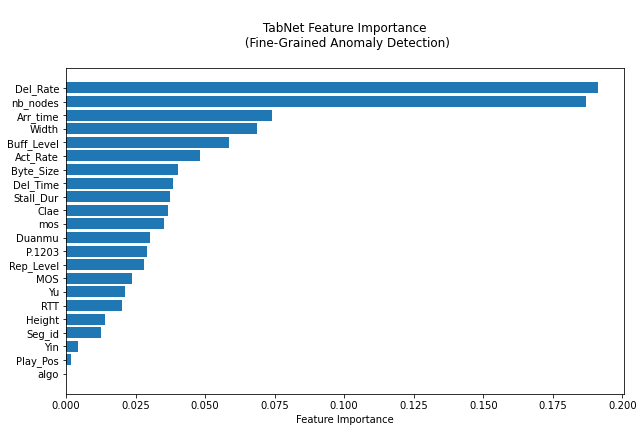

In [45]:
feature_importance = acc_clf.feature_importances_

# Map feature names to importance scores
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("\n TabNet Feature Importance \n (Fine-Grained Anomaly Detection)\n")
plt.show()

#### _Local explainability and masks_

In [46]:
explain_matrix, masks = acc_clf.explain(X_test)
print (masks.keys())
masks[0][:50].shape

dict_keys([0, 1, 2])


(50, 22)

In [47]:
len(features)

22

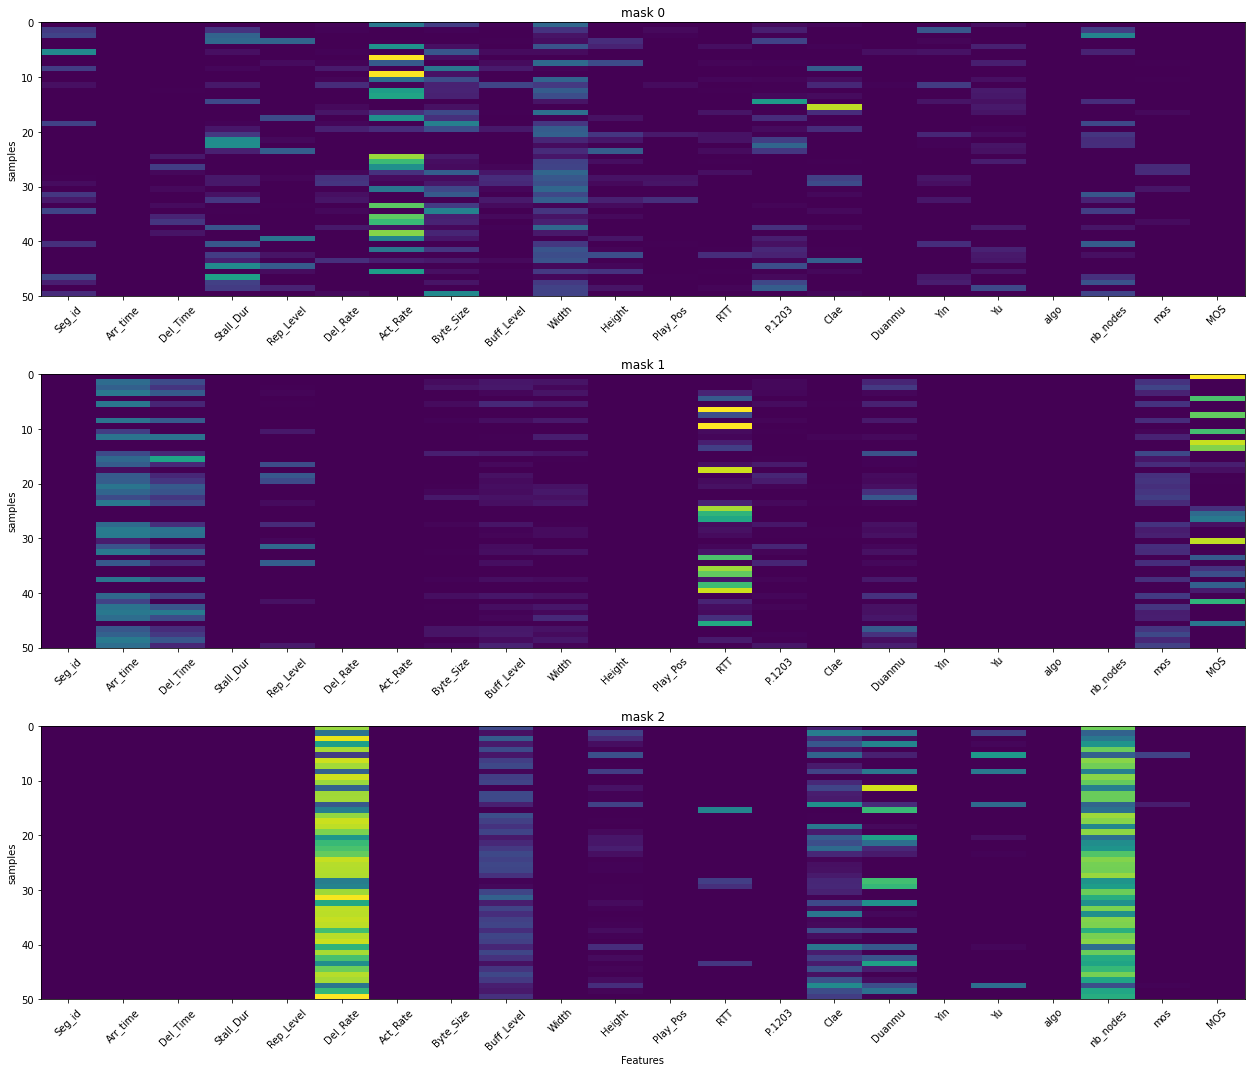

In [48]:
fig, axs = plt.subplots(3, 1, figsize=(20,15))
features_index = [x*20+10 for x in range(len(features))]
for i in range(3):
    axs[i].set_xticks(features_index)
    axs[i].imshow(masks[i][:50], extent=[0, 440, 50, 0], aspect=2)
    axs[i].set_xticklabels(features, rotation=45)
    axs[i].set_title(f"mask {i}")
    axs[i].set_ylabel("samples")    
axs[i].set_xlabel("Features")    
fig.tight_layout()

### _2. Using logloss_

In [49]:
tabnet_params = {"cat_idxs":cat_idxs,
                 "cat_dims":cat_dims,
                 "cat_emb_dim":2,
                 "optimizer_fn":torch.optim.Adam,
                 "optimizer_params":dict(lr=2e-2),
                 "scheduler_params":{"step_size":50, # how to use learning rate scheduler
                                 "gamma":0.9},
                 "scheduler_fn":torch.optim.lr_scheduler.StepLR,
                 "mask_type":'entmax', # "sparsemax"
                 # "grouped_features" : grouped_features,
                 "device_name" : "auto"                 
                }

loss_clf = TabNetClassifier(**tabnet_params)

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [50]:
# This illustrates the warm_start=False behaviour
save_history = []
start_time = time.time()

# Fitting the model without starting from a warm start nor computing the feature importance
for _ in range(2):
    loss_clf.fit(
        X_train=X_train, y_train=y_train,
        eval_set=[(X_train, y_train), (X_valid, y_valid)],
        eval_name=['train', 'valid'],
        eval_metric=['logloss'],
        max_epochs=max_epochs , # patience=20,
        batch_size=1024, virtual_batch_size=128,
        num_workers=0,
        weights=1,
        drop_last=False,
        augmentations=aug, #aug, None
        compute_importance=True
    )
    save_history.append(loss_clf.history["valid_logloss"])

assert(np.all(np.array(save_history[0]==np.array(save_history[1]))))

print(f"Training completed in {(time.time()-start_time)//60:.2f} mnt.")

epoch 0  | loss: 2.77458 | train_logloss: 2.43588 | valid_logloss: 2.43536 |  0:00:05s
epoch 1  | loss: 2.2536  | train_logloss: 2.13892 | valid_logloss: 2.13702 |  0:00:11s
epoch 2  | loss: 2.06995 | train_logloss: 2.03829 | valid_logloss: 2.03107 |  0:00:17s
epoch 3  | loss: 1.95192 | train_logloss: 1.77677 | valid_logloss: 1.774   |  0:00:22s
epoch 4  | loss: 1.8489  | train_logloss: 1.62409 | valid_logloss: 1.61115 |  0:00:28s
epoch 5  | loss: 1.7669  | train_logloss: 1.79667 | valid_logloss: 1.79118 |  0:00:34s
epoch 6  | loss: 1.72624 | train_logloss: 1.56518 | valid_logloss: 1.55827 |  0:00:41s
epoch 7  | loss: 1.71184 | train_logloss: 1.72095 | valid_logloss: 1.71743 |  0:00:47s
epoch 8  | loss: 1.66729 | train_logloss: 1.946   | valid_logloss: 1.94264 |  0:00:53s
epoch 9  | loss: 1.65996 | train_logloss: 1.62251 | valid_logloss: 1.62003 |  0:00:58s
epoch 10 | loss: 1.62647 | train_logloss: 1.40402 | valid_logloss: 1.39448 |  0:01:04s
epoch 11 | loss: 1.62119 | train_logloss: 1

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


epoch 0  | loss: 2.77458 | train_logloss: 2.43588 | valid_logloss: 2.43536 |  0:00:05s
epoch 1  | loss: 2.2536  | train_logloss: 2.13892 | valid_logloss: 2.13702 |  0:00:11s
epoch 2  | loss: 2.06995 | train_logloss: 2.03829 | valid_logloss: 2.03107 |  0:00:16s
epoch 3  | loss: 1.95192 | train_logloss: 1.77677 | valid_logloss: 1.774   |  0:00:22s
epoch 4  | loss: 1.8489  | train_logloss: 1.62409 | valid_logloss: 1.61115 |  0:00:28s
epoch 5  | loss: 1.7669  | train_logloss: 1.79667 | valid_logloss: 1.79118 |  0:00:34s
epoch 6  | loss: 1.72624 | train_logloss: 1.56518 | valid_logloss: 1.55827 |  0:00:39s
epoch 7  | loss: 1.71184 | train_logloss: 1.72095 | valid_logloss: 1.71743 |  0:00:45s
epoch 8  | loss: 1.66729 | train_logloss: 1.946   | valid_logloss: 1.94264 |  0:00:50s
epoch 9  | loss: 1.65996 | train_logloss: 1.62251 | valid_logloss: 1.62003 |  0:00:56s
epoch 10 | loss: 1.62647 | train_logloss: 1.40402 | valid_logloss: 1.39448 |  0:01:02s
epoch 11 | loss: 1.62119 | train_logloss: 1

C:\Users\kabou\.conda\envs\py37\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training completed in 10.00 mnt.


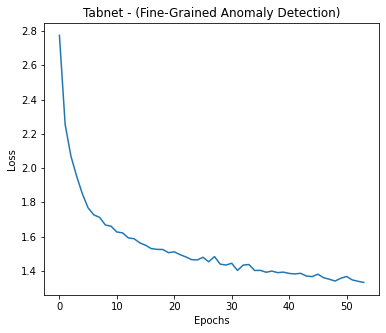

In [51]:
# plot losses
plt.figure(figsize=(6,5))
plt.plot(loss_clf.history['loss'])
plt.title('Tabnet - (Fine-Grained Anomaly Detection)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
#plt.legend()
plt.show()

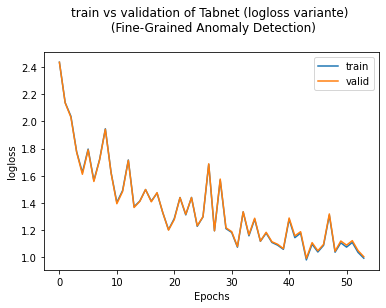

In [52]:
# plot logloss
plt.plot(loss_clf.history['train_logloss'], label="train")
plt.plot(loss_clf.history['valid_logloss'], label="valid")
plt.title('train vs validation of Tabnet (logloss variante) \n (Fine-Grained Anomaly Detection)\n')
plt.xlabel('Epochs')
plt.ylabel('logloss')
plt.legend()

In [53]:
# check that best weights are used
# assert np.isclose(valid_auc, np.max(clf.history['valid_logloss']), atol=1e-6)

In [54]:
loss_clf.predict(X_test)

array([ 2, 15, 10, ...,  0, 10, 18], dtype=int64)

##### _Evaluate_

In [55]:
from sklearn.metrics import silhouette_score, accuracy_score, mean_squared_error, r2_score

# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_valid = loss_clf.predict(X_valid)
y_pred_train = loss_clf.predict(X_train)
y_pred_test = loss_clf.predict(X_test)

# Calculate accuracy
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Validation Accuracy:", valid_accuracy)
print("Train Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Validation Accuracy: 0.6404538683956891
Train Accuracy: 0.6431544359255202
Test Accuracy: 0.6348130841121495


Evaluate using test set :

In [56]:
# Assuming clf_xgb is your trained XGBoost model
# X_valid and y_valid are your validation data
y_pred_test = loss_clf.predict(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred_test)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.6348130841121495


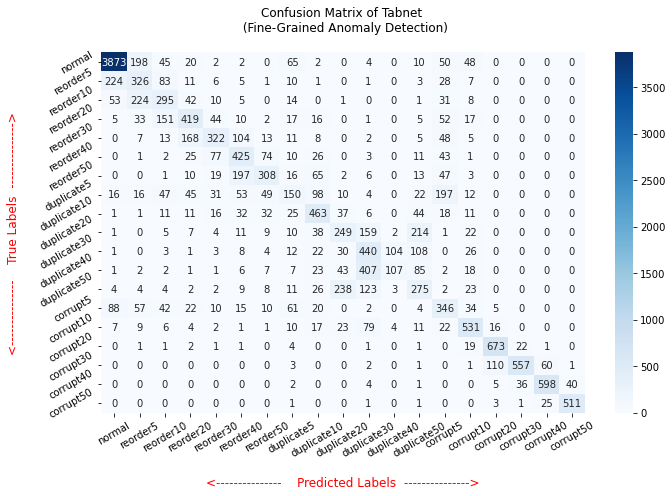

In [57]:
# Create a confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_test)

import seaborn as sns
import matplotlib.pyplot as plt


labaled_classes = [ 'normal', 
                    'reorder5', 'reorder10', 'reorder20', 
                    'reorder30', 'reorder40', 'reorder50',
                   'duplicate5', 'duplicate10', 'duplicate20', 
                    'duplicate30', 'duplicate40', 'duplicate50',        
                    'corrupt5',   'corrupt10',   'corrupt20', 
                    'corrupt30',  'corrupt40',  'corrupt50']

classes = np.unique(y_train) 
classes = [classe+0.5 for classe in classes]

# Create a heatmap for the confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.xticks(classes, labeled_classes, rotation=30)
plt.yticks(classes, labeled_classes, rotation=30)
plt.xlabel("<---------------    Predicted Labels  --------------->", fontsize=12, color="red", labelpad=18)
plt.ylabel("<---------------    True Labels  --------------->",  fontsize=12, color="red", labelpad=18)
plt.title('Confusion Matrix of Tabnet \n (Fine-Grained Anomaly Detection)\n')
plt.tight_layout()
plt.show()

In [58]:
# Display a classification report
print("                  TabNet Classification Report")
print("                (Fine-Grained Anomaly Detection)\n")
print(classification_report(y_test, y_pred_test))

                  TabNet Classification Report
                (Fine-Grained Anomaly Detection)

              precision    recall  f1-score   support

           0       0.91      0.90      0.90      4319
           1       0.37      0.46      0.41       706
           2       0.41      0.43      0.42       684
           3       0.53      0.54      0.54       772
           4       0.59      0.46      0.51       706
           5       0.48      0.61      0.54       698
           6       0.59      0.45      0.51       687
           7       0.34      0.20      0.25       750
           8       0.56      0.65      0.60       708
           9       0.39      0.34      0.36       732
          10       0.35      0.58      0.44       762
          11       0.49      0.15      0.23       712
          12       0.34      0.37      0.36       734
          13       0.39      0.48      0.43       716
          14       0.68      0.71      0.69       743
          15       0.83      0.93     

#### _Global explainability : feat importance summing to 1_

In [59]:
scorez = loss_clf.feature_importances_

# Sort features based on their absolute coefficients
feature_importance = pd.DataFrame({'feature': features, 'score': scorez})
feature_importance = feature_importance.sort_values(by='score', ascending=False)
feature_importance['f_indice'] = feature_importance.index
feature_importance = feature_importance.reset_index().drop(["index"], axis=1)
feature_importance['rank'] = feature_importance.index+1
feature_importance.head(20)

,feature,score,f_indice,rank
0,Del_Rate,0.204094,5,1
1,nb_nodes,0.178514,19,2
2,Width,0.080141,9,3
3,Buff_Level,0.072679,8,4
4,Arr_time,0.062833,1,5
5,Clae,0.045160,14,6
6,Act_Rate,0.043825,6,7
7,Byte_Size,0.035559,7,8
8,mos,0.031663,20,9
9,Del_Time,0.030016,2,10


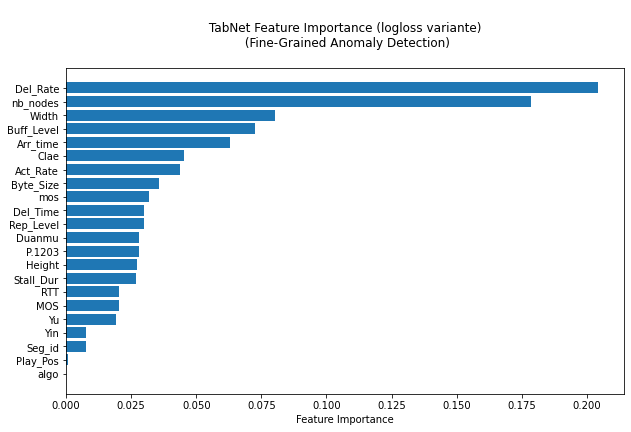

In [60]:
feature_importance = loss_clf.feature_importances_

# Map feature names to importance scores
# feature_names = [f'Feature {i}' for i in range(X_train.shape[1])]
feature_names = [features[i] for i in range(X_train.shape[1])]
feature_importance_dict = dict(zip(feature_names, feature_importance))

# Sort features by importance
sorted_features = sorted(feature_importance_dict.items(), key=lambda x: x[1])

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_features)), [importance for feature, importance in sorted_features], align="center")
plt.yticks(range(len(sorted_features)), [feature for feature, importance in sorted_features])
plt.xlabel("Feature Importance")
plt.title("\n TabNet Feature Importance (logloss variante) \n (Fine-Grained Anomaly Detection)\n")
plt.show()

#### _Local explainability and masks_

In [61]:
explain_matrix, masks = loss_clf.explain(X_test)
print (masks.keys())
masks[0][:50].shape

dict_keys([0, 1, 2])


(50, 22)

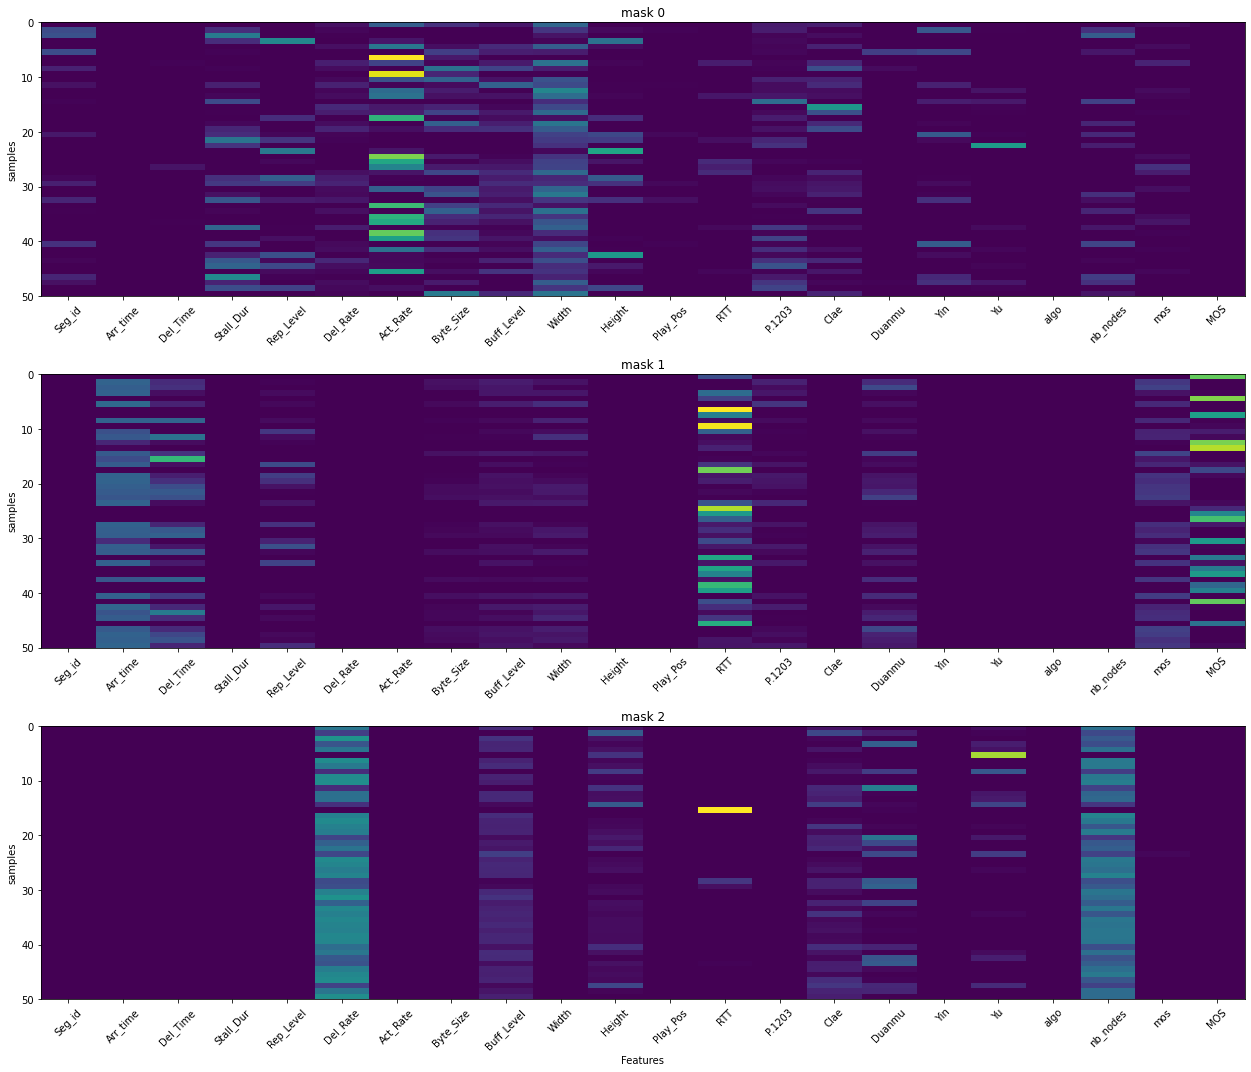

In [62]:
fig, axs = plt.subplots(3, 1, figsize=(20,15))
features_index = [x*20+10 for x in range(len(features))]
for i in range(3):
    axs[i].set_xticks(features_index)
    axs[i].imshow(masks[i][:50], extent=[0, 440, 50, 0], aspect=2)
    # axs[i].set(xticks=np.linspace(0, 23), xticklabels=np.linspace(0, 23), yticks=[0, 50], yticklabels=[0, 1]);    
    axs[i].set_xticklabels(features, rotation=45)
    axs[i].set_title(f"mask {i}")
    axs[i].set_ylabel("samples")    
axs[i].set_xlabel("Features")    
fig.tight_layout()

_**c. Discussion**_

As we saw in the results, using either accuracy or logloss does not has a considerable impact on the performance of our TabNet model.

Nevertheless, considering the little enhancement given by "accuracy", we pick it as a representative of TabNet in multi-class anomaly detection approach.